In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "results/{0}_fig7_rho_sub_critical.p"
N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
num_ensambles = 6000
M = np.empty((len(N_range), num_ensambles))

In [3]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

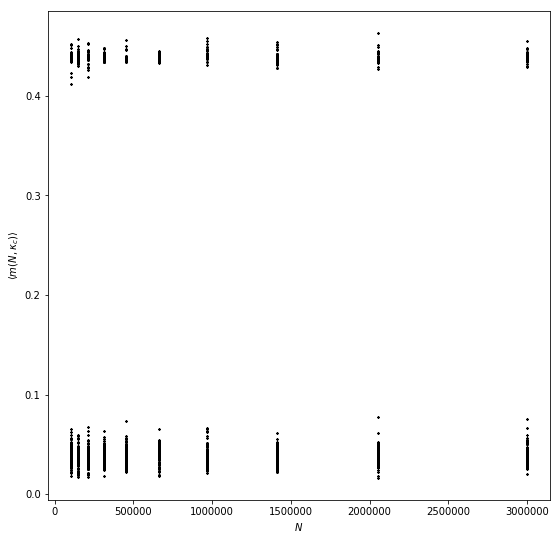

In [5]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.plot(N_range, M[:, n], 'ko', ms=0.5)
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$')
plt.show()

In [20]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], -np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

In [34]:
z = np.polyfit(np.log(pairs[:, 0]), pairs[:, 1], 1)
print(z)
p = np.poly1d(z)

[-0.00032194 -0.034551  ]


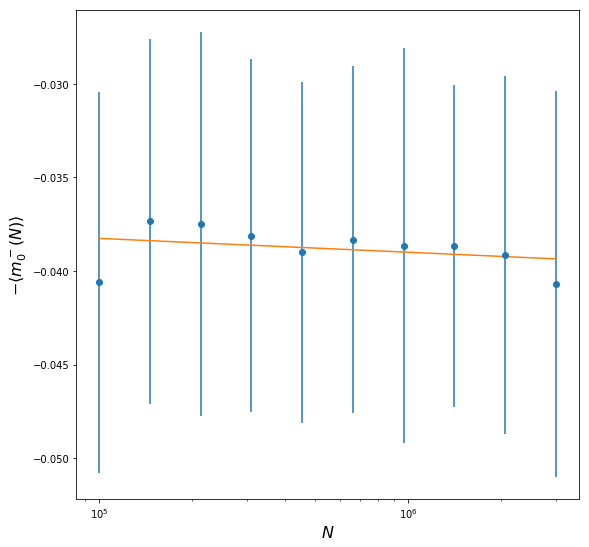

In [35]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$-\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

In [16]:
pairs[:,0]

array([ 100000.,  145923.,  212936.,  310723.,  453417.,  661641.,
        965489., 1408873., 2055874., 3000000.])